# 1. Import libraries

In [1]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

import joblib

warnings.filterwarnings("ignore")


# 2. Load Dataset

In [2]:
# Load clean data
df = pd.read_csv("/kaggle/input/datasets/mahendrapalsaniya/retail-cleaned-dataset/online_retail_featured.csv")
df.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,CustomerID,Country,TotalSales,Year,Month,Day,Hour,DayOfWeek,Quarter,YearMonth,IsWeekend
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085,United Kingdom,83.4,2009,12,1,7,1,4,2009-12,0
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085,United Kingdom,81.0,2009,12,1,7,1,4,2009-12,0
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085,United Kingdom,81.0,2009,12,1,7,1,4,2009-12,0
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085,United Kingdom,100.8,2009,12,1,7,1,4,2009-12,0
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085,United Kingdom,30.0,2009,12,1,7,1,4,2009-12,0


In [3]:
# Basic Information

print("Data loaded!")
print("Main dataset:", df.shape)

print("Data Info:\n")
display(df.info())
print("basic statistics")
display(df.describe())

Data loaded!
Main dataset: (779425, 17)
Data Info:

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 779425 entries, 0 to 779424
Data columns (total 17 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   Invoice      779425 non-null  int64  
 1   StockCode    779425 non-null  object 
 2   Description  779425 non-null  object 
 3   Quantity     779425 non-null  int64  
 4   InvoiceDate  779425 non-null  object 
 5   Price        779425 non-null  float64
 6   CustomerID   779425 non-null  int64  
 7   Country      779425 non-null  object 
 8   TotalSales   779425 non-null  float64
 9   Year         779425 non-null  int64  
 10  Month        779425 non-null  int64  
 11  Day          779425 non-null  int64  
 12  Hour         779425 non-null  int64  
 13  DayOfWeek    779425 non-null  int64  
 14  Quarter      779425 non-null  int64  
 15  YearMonth    779425 non-null  object 
 16  IsWeekend    779425 non-null  int64  
dtypes: float64(2), 

None

basic statistics


,Invoice,Quantity,Price,CustomerID,TotalSales,Year,Month,Day,Hour,DayOfWeek,Quarter,IsWeekend
count,779425.000000,779425.000000,779425.000000,779425.000000,779425.000000,779425.000000,779425.000000,779425.000000,779425.000000,779425.000000,779425.000000,779425.000000
mean,537426.828586,13.489370,3.218488,15320.360461,22.291823,2010.432051,7.417059,15.390961,12.791884,2.641669,2.796884,0.167479
std,26901.629627,145.855814,29.676140,1695.692775,227.427075,0.568385,3.422319,8.657939,2.294182,1.951163,1.132107,0.373403
min,489434.000000,1.000000,0.001000,12346.000000,0.001000,2009.000000,1.000000,1.000000,6.000000,0.000000,1.000000,0.000000
25%,514483.000000,2.000000,1.250000,13971.000000,4.950000,2010.000000,5.000000,8.000000,11.000000,1.000000,2.000000,0.000000
50%,536754.000000,6.000000,1.950000,15247.000000,12.480000,2010.000000,8.000000,15.000000,13.000000,2.000000,3.000000,0.000000
75%,561995.000000,12.000000,3.750000,16794.000000,19.800000,2011.000000,11.000000,23.000000,14.000000,4.000000,4.000000,0.000000
max,581587.000000,80995.000000,10953.500000,18287.000000,168469.600000,2011.000000,12.000000,31.000000,20.000000,6.000000,4.000000,1.000000


In [4]:
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])

print("\nColumns:", list(df.columns))
print(f'\nUnique SKUs: {df["StockCode"].nunique():,}')
print(f'Countries  : {df["Country"].nunique()}')


Columns: ['Invoice', 'StockCode', 'Description', 'Quantity', 'InvoiceDate', 'Price', 'CustomerID', 'Country', 'TotalSales', 'Year', 'Month', 'Day', 'Hour', 'DayOfWeek', 'Quarter', 'YearMonth', 'IsWeekend']

Unique SKUs: 4,631
Countries  : 41


# 3. Calculate Stats by per Product

In [5]:
# Calculate stats by per product 
product_stats = df.groupby(['StockCode', 'Description']).agg(
    Total_Quantity    = ('Quantity', 'sum'),
    Total_Revenue     = ('TotalSales', 'sum'),
    Avg_Daily_Qty     = ('Quantity', 'mean'),
    Std_Daily_Qty     = ('Quantity', 'std'),
    Num_Transactions  = ('Invoice', 'nunique'),
    Avg_Price         = ('Price', 'mean'),
    Last_Sale        = ('InvoiceDate',  'max'),
    First_Sale       = ('InvoiceDate',  'min'),
).reset_index()

# Remove system entries
product_stats = product_stats[
    ~product_stats['Description'].str.contains(
        'POSTAGE|MANUAL|DOTCOM|CRUK|AMAZONFEE|BANK|discount',
        case=False, na=False)
]

# Sort by revenue
product_stats = product_stats.sort_values(
    'Total_Revenue', ascending=False).reset_index(drop=True)

print("Product stats calculated!")
print("Total products:", len(product_stats))
print("\nTop 10 products by revenue:")
print(product_stats[['Description','Total_Quantity','Total_Revenue'
                     ,'Avg_Price']].head(10))

Product stats calculated!
Total products: 5296

Top 10 products by revenue:
                          Description  Total_Quantity  Total_Revenue  \
0            REGENCY CAKESTAND 3 TIER           24124      277656.25   
1  WHITE HANGING HEART T-LIGHT HOLDER           91757      247048.01   
2         PAPER CRAFT , LITTLE BIRDIE           80995      168469.60   
3             JUMBO BAG RED RETROSPOT           74224      134307.44   
4       ASSORTED COLOUR BIRD ORNAMENT           78234      124351.86   
5                       PARTY BUNTING           23460      103283.38   
6      MEDIUM CERAMIC TOP STORAGE JAR           77916       81416.73   
7     PAPER CHAIN KIT 50'S CHRISTMAS            28380       76598.18   
8                       CHILLI LIGHTS           14843       69084.30   
9                JUMBO BAG STRAWBERRY           35842       64127.77   

   Avg_Price  
0  12.461649  
1   2.870666  
2   2.080000  
3   1.973870  
4   1.676152  
5   4.772912  
6   1.220303  
7   2.91960

# 4. EOQ (Economic Order Quantity)

In [6]:
# EOQ = Economic Order Quantity
# Formula: EOQ = sqrt(2 * D * S / H)
# D = Annual demand, S = Order cost, H = Holding cost

# Constants (industry standard assumptions)
ORDER_COST    = 50    # 50 per order placed
HOLDING_RATE  = 0.20  # 20% of item value per year to hold
LEAD_TIME     = 7     # 7 days from order to delivery
SERVICE_LEVEL = 1.65  # 95% service level (Z-score)
DAYS_IN_DATA  = 604   # days in our dataset

# Calculate daily demand per product
product_stats['Daily_Demand'] = (
    product_stats['Total_Quantity'] / DAYS_IN_DATA
)

# Annual demand
product_stats['Annual_Demand'] = product_stats['Daily_Demand'] * 365

# Holding cost per unit per year
product_stats['Holding_Cost'] = (
    product_stats['Avg_Price'] * HOLDING_RATE
)

# EOQ formula
product_stats['EOQ'] = np.sqrt(
    (2 * product_stats['Annual_Demand'] * ORDER_COST) /
    product_stats['Holding_Cost'].replace(0, 0.01)
).round(0)

# Safety stock = Z * std_demand * sqrt(lead_time)
product_stats['Safety_Stock'] = (
    SERVICE_LEVEL *
    product_stats['Std_Daily_Qty'].fillna(0) *
    np.sqrt(LEAD_TIME)
).round(0)

# Reorder Point = (Daily demand * Lead time) + Safety stock
product_stats['Reorder_Point'] = (
    product_stats['Daily_Demand'] * LEAD_TIME +
    product_stats['Safety_Stock']
).round(0)

# Max Stock Level
product_stats['Max_Stock'] = (
    product_stats['Reorder_Point'] + product_stats['EOQ']
).round(0)

print("Inventory calculations complete!")
print()
print("Top 10 products — Inventory Plan:")
cols = ['Description','Daily_Demand','EOQ',
        'Safety_Stock','Reorder_Point',]
print(product_stats[cols].head(10).to_string(index=False))


Inventory calculations complete!

Top 10 products — Inventory Plan:
                       Description  Daily_Demand    EOQ  Safety_Stock  Reorder_Point
          REGENCY CAKESTAND 3 TIER     39.940397  765.0          75.0          355.0
WHITE HANGING HEART T-LIGHT HOLDER    151.915563 3108.0         262.0         1325.0
       PAPER CRAFT , LITTLE BIRDIE    134.097682 3430.0           0.0          939.0
           JUMBO BAG RED RETROSPOT    122.887417 3371.0         273.0         1133.0
     ASSORTED COLOUR BIRD ORNAMENT    129.526490 3755.0         431.0         1338.0
                     PARTY BUNTING     38.841060 1219.0          88.0          360.0
    MEDIUM CERAMIC TOP STORAGE JAR    129.000000 4392.0       23019.0        23922.0
   PAPER CHAIN KIT 50'S CHRISTMAS      46.986755 1714.0         211.0          540.0
                     CHILLI LIGHTS     24.574503  934.0         161.0          333.0
              JUMBO BAG STRAWBERRY     59.341060 2352.0         233.0          648

# 5. ABC-Classification

In [7]:
# ABC Classification (Revenue-Based) 
total_revenue = product_stats['Total_Revenue'].sum()
product_stats['Revenue_Pct'] = product_stats['Total_Revenue'] / total_revenue * 100
product_stats['Cumulative_Revenue_Pct'] = product_stats['Revenue_Pct'].cumsum()

def abc_class(row):
    if row['Cumulative_Revenue_Pct'] <= 80:
        return 'A'   # High-value  — 80% of revenue
    elif row['Cumulative_Revenue_Pct'] <= 95:
        return 'B'   # Medium-value — next 15%
    else:
        return 'C'   # Low-value   — bottom 5%

product_stats['ABC_Class'] = product_stats.apply(abc_class, axis=1)

print('📈 ABC Classification Summary:')
for cls in ['A','B','C']:
    n   = (product_stats['ABC_Class'] == cls).sum()
    pct_items = n / len(product_stats) * 100
    rev = product_stats[product_stats['ABC_Class'] == cls]['Total_Revenue'].sum()
    pct_rev = rev / total_revenue * 100
    print(f"  Class {cls}: {n:5d} SKUs ({pct_items:5.1f}% of items) → £{rev:>12,.0f} ({pct_rev:5.1f}% of revenue)")

# Avg EOQ by class
print()
print(product_stats.groupby('ABC_Class')[['EOQ','Safety_Stock'
                                          ,'Reorder_Point']].mean().round(1))

📈 ABC Classification Summary:
  Class A:  1148 SKUs ( 21.7% of items) → £  13,635,564 ( 80.0% of revenue)
  Class B:  1361 SKUs ( 25.7% of items) → £   2,557,243 ( 15.0% of revenue)
  Class C:  2787 SKUs ( 52.6% of items) → £     852,849 (  5.0% of revenue)

             EOQ  Safety_Stock  Reorder_Point
ABC_Class                                    
A          944.8         180.7          253.4
B          619.4         200.9          220.7
C          246.7         111.2          115.1


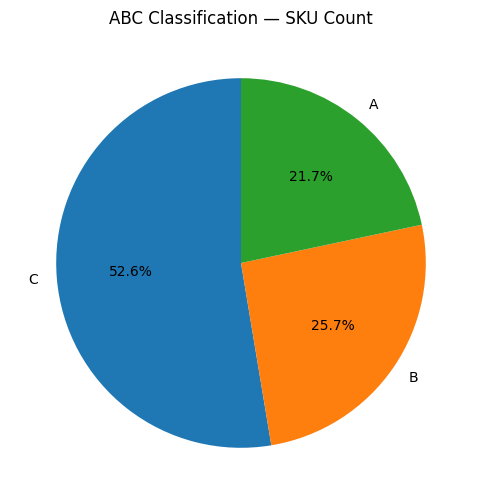

In [8]:
# Count A, B, and C SKUs
abc_count = product_stats['ABC_Class'].value_counts()

# Plot pie chart
plt.figure(figsize=(6,6))
plt.pie(abc_count,
        labels=abc_count.index,
        autopct='%1.1f%%',
        startangle=90)

plt.title("ABC Classification — SKU Count")
plt.savefig('ABC_Count.png', dpi=150)
plt.show()

# 6. XYZ-Classification

In [9]:
# XYZ Classification (Demand Variability) 
# Coefficient of Variation = σ / μ
product_stats['CV'] = (
    product_stats['Std_Daily_Qty'].fillna(0) /
    product_stats['Avg_Daily_Qty'].replace(0, np.nan)
).fillna(999)

def xyz_class(cv):
    if   cv <= 0.5: return 'X'  # Stable — can use fixed reorder policy
    elif cv <= 1.0: return 'Y'  # Variable — use safety stock buffer
    else:           return 'Z'  # Irregular — use on-demand 

product_stats['XYZ_Class'] = product_stats['CV'].apply(xyz_class)
product_stats['ABC_XYZ']   = product_stats['ABC_Class'] + product_stats['XYZ_Class']

print('📊 XYZ Classification Summary:')
print(product_stats.groupby('XYZ_Class').agg(
    Count  =('StockCode','count'),
    Avg_CV =('CV','mean')
).round(3))

print('\n📊 ABC-XYZ Matrix (SKU counts):')
matrix = pd.crosstab(product_stats['ABC_Class'], product_stats['XYZ_Class'])
print(matrix)

print('\n📋 Recommended Replenishment Policy per Segment:')
policies = {
    'AX': 'Continuous review — tight, precise control',
    'AY': 'Fixed-period review with safety stock buffer',
    'AZ': 'Just-in-time / consignment; close supplier collaboration',
    'BX': 'Periodic review — automated reorder',
    'BY': 'Periodic review with larger safety stock',
    'BZ': 'Manual review — keep minimum stock',
    'CX': 'Bulk annual order to minimise order cost',
    'CY': 'Infrequent replenishment — monitor quarterly',
    'CZ': 'Consider phase-out; flag for dead-stock review',
}
for seg, policy in policies.items():
    cnt = (product_stats['ABC_XYZ'] == seg).sum()
    print(f'  {seg}: {cnt:4d} SKUs — {policy}')

📊 XYZ Classification Summary:
           Count  Avg_CV
XYZ_Class               
X            629   0.190
Y           1222   0.778
Z           3445   2.045

📊 ABC-XYZ Matrix (SKU counts):
XYZ_Class    X    Y     Z
ABC_Class                
A            6   39  1103
B           13  231  1117
C          610  952  1225

📋 Recommended Replenishment Policy per Segment:
  AX:    6 SKUs — Continuous review — tight, precise control
  AY:   39 SKUs — Fixed-period review with safety stock buffer
  AZ: 1103 SKUs — Just-in-time / consignment; close supplier collaboration
  BX:   13 SKUs — Periodic review — automated reorder
  BY:  231 SKUs — Periodic review with larger safety stock
  BZ: 1117 SKUs — Manual review — keep minimum stock
  CX:  610 SKUs — Bulk annual order to minimise order cost
  CY:  952 SKUs — Infrequent replenishment — monitor quarterly
  CZ: 1225 SKUs — Consider phase-out; flag for dead-stock review


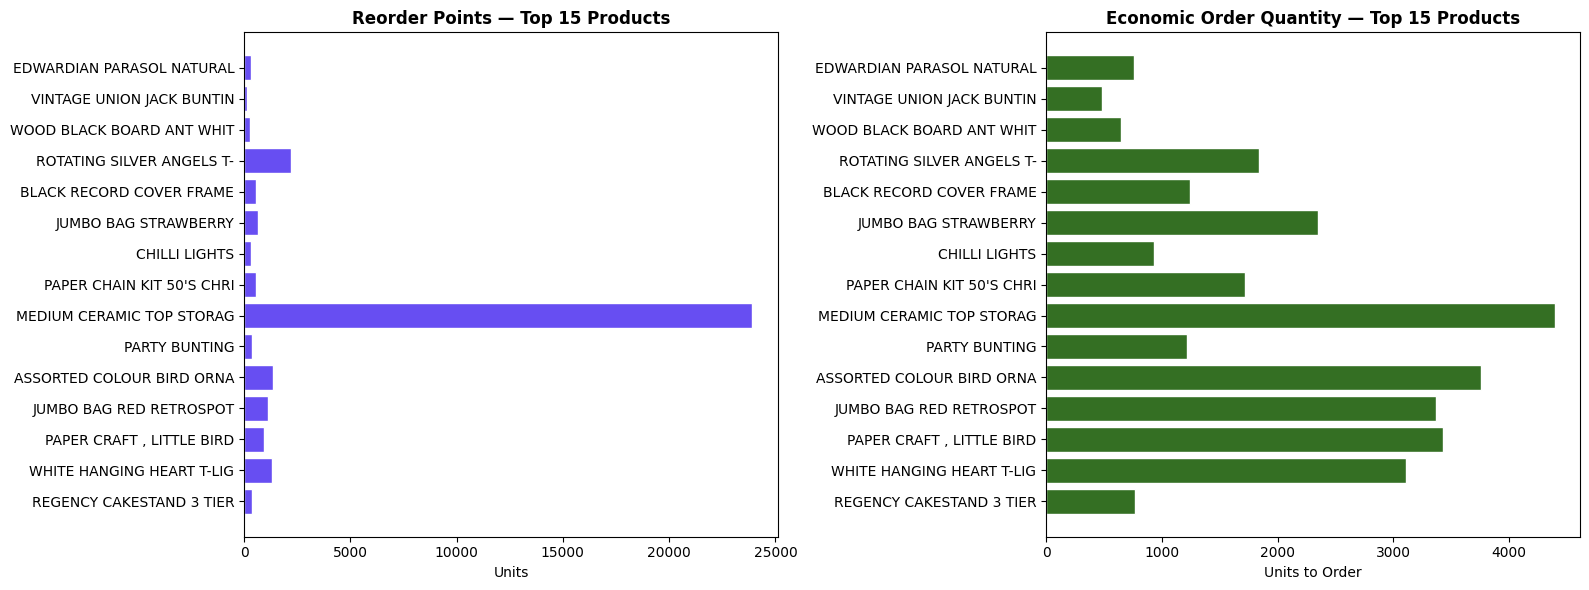

Inventory plot saved!


In [10]:
# Plot top 15 products — Reorder Points vs Safety Stock
top15 = product_stats.head(15).copy()
top15['Short_Name'] = top15['Description'].str[:25]

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Reorder points
axes[0].barh(top15['Short_Name'], top15['Reorder_Point'],
             color='#674EF2', edgecolor='white')
axes[0].set_title('Reorder Points — Top 15 Products',
                  fontweight='bold', fontsize=12)
axes[0].set_xlabel('Units')

# EOQ
axes[1].barh(top15['Short_Name'], top15['EOQ'],
             color='#346F23', edgecolor='white')
axes[1].set_title('Economic Order Quantity — Top 15 Products',
                  fontweight='bold', fontsize=12)
axes[1].set_xlabel('Units to Order')

plt.tight_layout()
plt.savefig('inventory_plan.png', dpi=150)
plt.show()
print("Inventory plot saved!")

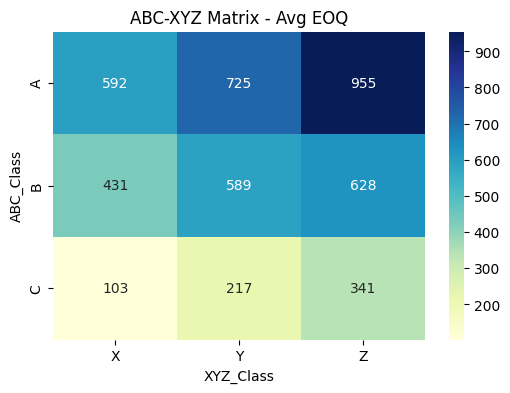

In [11]:
heatmap_data = product_stats.pivot_table(
    values='EOQ',
    index='ABC_Class',
    columns='XYZ_Class',
    aggfunc='mean'
)

plt.figure(figsize=(6,4))
sns.heatmap(heatmap_data, annot=True, fmt=".0f", cmap="YlGnBu")

plt.title("ABC-XYZ Matrix - Avg EOQ")
plt.savefig('ABC-XYZ Matrix.png', dpi=150)
plt.show()

# 7. Calculate Dead-Stocks

In [12]:
# Dead-Stock Risk Scoring
# Multi-factor risk model (max 100 pts)


reference_date = df['InvoiceDate'].max()

product_stats['Days_Since_Last_Sale']  = (
    (reference_date - pd.to_datetime(product_stats['Last_Sale'])).dt.days
)
product_stats['Product_Lifespan_Days'] = (
    (pd.to_datetime(product_stats['Last_Sale']) -
     pd.to_datetime(product_stats['First_Sale'])).dt.days + 1
)
product_stats['Txn_Frequency'] = (
    product_stats['Num_Transactions'] /
    product_stats['Product_Lifespan_Days'].replace(0, 1)
)

# Component scores
max_days = product_stats['Days_Since_Last_Sale'].quantile(0.95)
max_freq = product_stats['Txn_Frequency'].quantile(0.95)

score_staleness    = product_stats['Days_Since_Last_Sale'].clip(upper=max_days) / max_days * 40
score_frequency    = (1 - product_stats['Txn_Frequency'].clip(upper=max_freq) / max_freq) * 30
score_variability  = product_stats['CV'].clip(upper=3) / 3 * 20
score_revenue      = (1 - product_stats['Revenue_Pct'] / product_stats['Revenue_Pct'].max()) * 10

product_stats['DeadStock_Score'] = (
    score_staleness + score_frequency + score_variability + score_revenue
).clip(0, 100).round(1)

product_stats['DeadStock_Risk'] = pd.cut(
    product_stats['DeadStock_Score'],
    bins=[-1, 30, 55, 75, 100],
    labels=['Low', 'Medium', 'High', 'Critical']
)

print('Dead-Stock Risk Distribution:')
for tier in ['Low','Medium','High','Critical']:
    n   = (product_stats['DeadStock_Risk'] == tier).sum()
    pct = n / len(product_stats) * 100
    print(f'  {tier:10s}: {n:5d} SKUs ({pct:.1f}%)')


Dead-Stock Risk Distribution:
  Low       :   391 SKUs (7.4%)
  Medium    :  2903 SKUs (54.8%)
  High      :  1421 SKUs (26.8%)
  Critical  :   581 SKUs (11.0%)


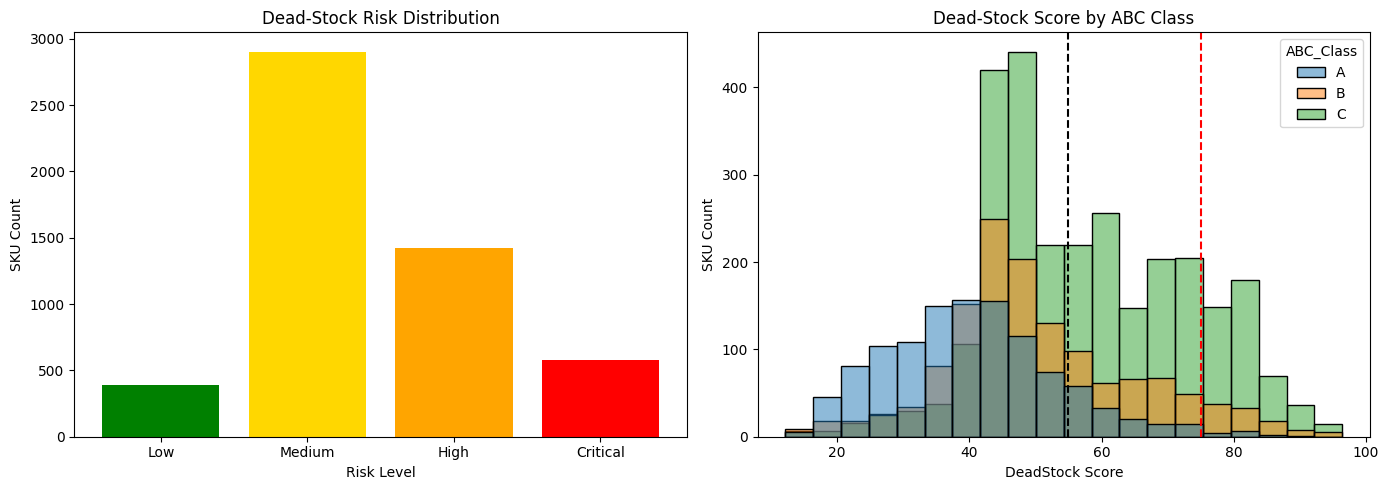

In [13]:
fig, ax = plt.subplots(1, 2, figsize=(14,5))

# ---------------- Left Plot ----------------
risk_count = product_stats['DeadStock_Risk'].value_counts().reindex(
    ['Low','Medium','High','Critical']
)

ax[0].bar(
    risk_count.index,
    risk_count.values,
    color=['green','gold','orange','red']
)

ax[0].set_title("Dead-Stock Risk Distribution")
ax[0].set_xlabel("Risk Level")
ax[0].set_ylabel("SKU Count")

# ---------------- Right Plot ----------------
sns.histplot(
    data=product_stats,
    x='DeadStock_Score',
    hue='ABC_Class',
    bins=20,
    multiple='layer',
    ax=ax[1]
)

ax[1].axvline(55, color='black', linestyle='--')
ax[1].axvline(75, color='red', linestyle='--')

ax[1].set_title("Dead-Stock Score by ABC Class")
ax[1].set_xlabel("DeadStock Score")
ax[1].set_ylabel("SKU Count")
plt.savefig('Dead_stock_distribution.png', dpi=150)
plt.tight_layout()
plt.show()

In [14]:
# Full inventory plan
export_cols = [
    'StockCode','Description','ABC_Class','XYZ_Class','ABC_XYZ',
    'Daily_Demand','Avg_Price','Annual_Demand',
    'EOQ','Safety_Stock','Reorder_Point','Max_Stock',
    'Holding_Cost','Product_Lifespan_Days',
    'DeadStock_Score','DeadStock_Risk',
    'Days_Since_Last_Sale','Num_Transactions','Total_Revenue',
]
product_stats[export_cols].to_csv('inventory_plan.csv', index=False)
